In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score


In [6]:
df = pd.read_csv('TS.csv')
df['Time'] = pd.to_datetime(df['Time'], format='%m/%d/%y %H:%M')
df.set_index('Time', inplace=True)
df = df.asfreq('H')

print("Первые 5 строк:")
print(df.head())

Первые 5 строк:
                       Users
Time                        
2017-01-01 00:00:00  34002.0
2017-01-01 01:00:00  37947.0
2017-01-01 02:00:00  41517.0
2017-01-01 03:00:00  44476.0
2017-01-01 04:00:00  46234.0


/tmp/ipykernel_3259/113239914.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.asfreq('H')


In [7]:
if df['Users'].isnull().any():
    print(f"Найдено пропусков: {df['Users'].isnull().sum()}. Заполняем интерполяцией.")
    df['Users'].interpolate(method='linear', inplace=True)

print(df.head())

Найдено пропусков: 1. Заполняем интерполяцией.
                       Users
Time                        
2017-01-01 00:00:00  34002.0
2017-01-01 01:00:00  37947.0
2017-01-01 02:00:00  41517.0
2017-01-01 03:00:00  44476.0
2017-01-01 04:00:00  46234.0


/tmp/ipykernel_3259/1177391579.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Users'].interpolate(method='linear', inplace=True)


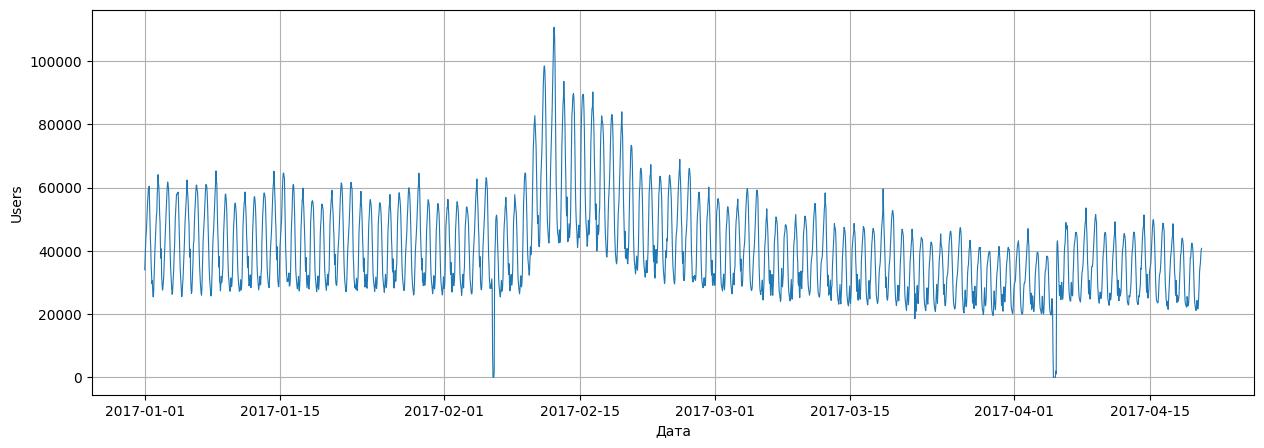

In [8]:
plt.figure(figsize=(15,5))
plt.plot(df.index, df['Users'], linewidth=0.8)
plt.xlabel('Дата')
plt.ylabel('Users')
plt.grid(True)
plt.show()

In [9]:
series = df['Users'].values.reshape(-1, 1)
scaler = StandardScaler()
scaled_series = scaler.fit_transform(series).flatten()

In [10]:
n_lags = 168
def create_lag_data(data, n_lags):
    X, y = [], []
    for i in range(n_lags, len(data)):
        X.append(data[i-n_lags:i])
        y.append(data[i])
    return np.array(X), np.array(y)

X, y = create_lag_data(scaled_series, n_lags)
print(f'Размер X: {X.shape} (окна, {n_lags} лагов)')
print(f'Размер y: {y.shape}')

Размер X: (2458, 168) (окна, 168 лагов)
Размер y: (2458,)


In [11]:
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [12]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [13]:
y_pred_test = model.predict(X_test)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_test_inv = scaler.inverse_transform(y_pred_test.reshape(-1, 1)).flatten()

mae_test = mean_absolute_error(y_test_inv, y_pred_test_inv)
r2 = r2_score(y_test_inv, y_pred_test_inv)

print(f'MAE на тесте: {mae_test:.2f} пользователей')
print(f'R² на тесте: {r2:.4f}')

MAE на тесте: 1264.14 пользователей
R² на тесте: 0.9415


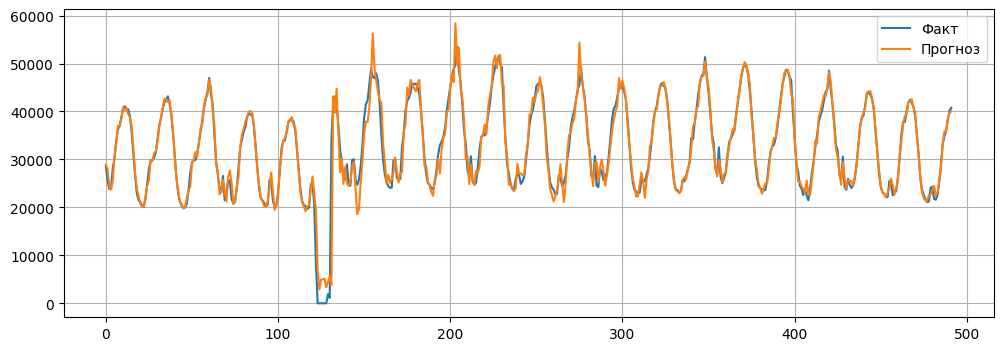

In [14]:
plt.figure(figsize=(12,4))
plt.plot(y_test_inv[:1000], label='Факт')
plt.plot(y_pred_test_inv[:1000], label='Прогноз')
plt.legend()
plt.grid(True)
plt.show()


In [15]:
future_steps = 720
last_window = scaled_series[-n_lags:].copy()
future_preds_scaled = []

for step in range(future_steps):
    next_pred = model.predict(last_window.reshape(1, -1))[0]
    future_preds_scaled.append(next_pred)
    last_window = np.roll(last_window, -1)
    last_window[-1] = next_pred

future_preds = scaler.inverse_transform(np.array(future_preds_scaled).reshape(-1, 1)).flatten()

last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(hours=1), periods=future_steps, freq='H')

/tmp/ipykernel_3259/3414275027.py:14: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_dates = pd.date_range(start=last_date + pd.Timedelta(hours=1), periods=future_steps, freq='H')


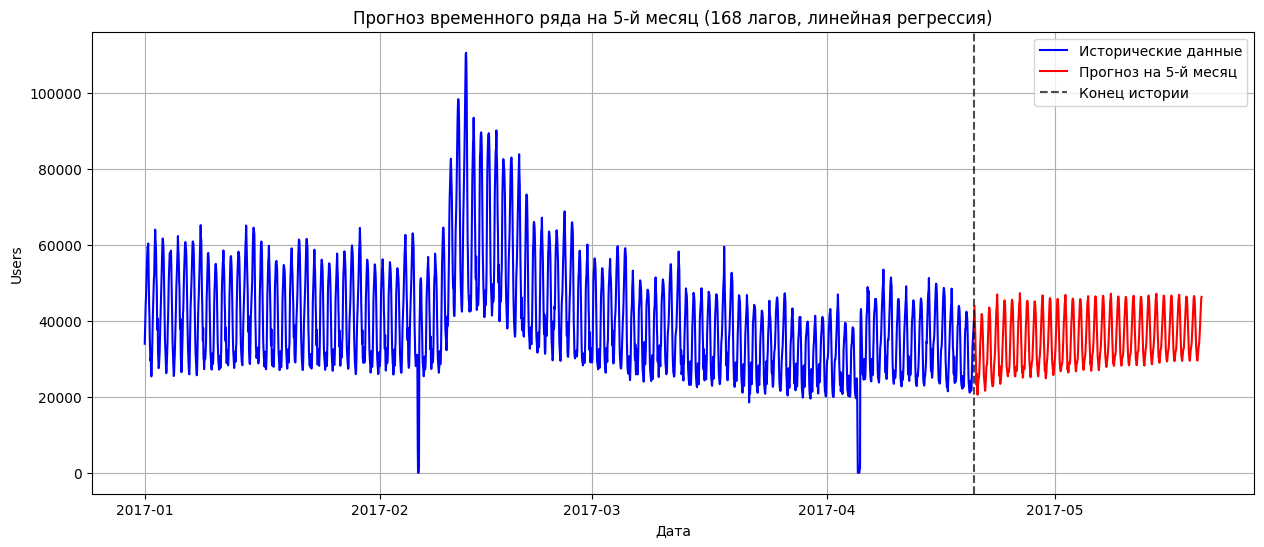

In [16]:
plt.figure(figsize=(15,6))
plt.plot(df.index, df['Users'], label='Исторические данные', color='blue')
plt.plot(future_dates, future_preds, label='Прогноз на 5-й месяц', color='red')
plt.axvline(x=df.index[-1], color='black', linestyle='--', alpha=0.7, label='Конец истории')
plt.title('Прогноз временного ряда на 5-й месяц (168 лагов, линейная регрессия)')
plt.xlabel('Дата')
plt.ylabel('Users')
plt.legend()
plt.grid(True)
plt.show()